# **Plots to compare results from different model**
---
All the plots are obtained from postprocessed output from each downscaling model. Currently, the models used to compare are [deepru](), [sha_unet](), [sha_wgan]() and [swinir](https://arxiv.org/abs/2108.10257)


### Prerequisites
* Numpy (tested with version 1.22.3)
* Xarray (tested with 2022.9.0)
* Metapostprocess (plotting routines developed by our team ``` ../postprocess/metapostprocess.py```)


In [1]:
# Import modules
%matplotlib inline
import os, sys
base_dir = "../../"
sys.path.extend([f"{base_dir}/postprocess"])
import numpy as np
import xarray as xr

# for plotting
from metapostprocess import *




 # **Line plot**
 ---
 Line plot compares the defined metric (e.g. RMSE) for each competitive model at each hour of the day. It helps us to understand the downscaling ability of model with respect to the time(hour) of the day. 
 
 ## **Config parameters**
 ---
 Define config parameters. All of these parameters are mandatory. An instance of **Config** class is used as a parameter for our plotting routines
 - Parameters of **Config**
     - base_folder : define the absolute path location where all the results for all the models are stored e.g. ```"/p/scratch/deepacf/maelstrom/maelstrom_data/ap5/downscaling_benchmark_dataset/benchmark_t2m/results"```
     - variable : downscaled variable e.g. ```"t2m"``` ( 3 variables have been downscaled "t2m","wind","solar_irradiance")
     - models : list of competitive model e.g. ```"deepru","sha_unet","sha_wgan","swinir"```. The name of these models should exactly match with their corresponding folder in the base_folder
     - seasons : define the analysis seasons or the whole year e.g. ```"year``` (available options are "year","DJF","JJA","MAM","SON" )
     - metric : deinfe the evaluation metric e.g. ```rmse``` ( available options are "bias","grad_amplitude","me_std","rmse")

 
 The parameters can be either directly passed an argument to an instance of **Config** or as done in this notebook define an empty dictionary and pass these parameter as keys with their corresponding values. Pass this ```**dictionary``` as an argument to the **Config** class 

In [2]:
#config parameters
config = {}
config['base_folder'] = "/p/scratch/deepacf/maelstrom/maelstrom_data/ap5/downscaling_benchmark_dataset/benchmark_t2m/results"
config['variable'] = "t2m"
config['models'] = ["deepru","sha_unet","sha_wgan","swinir"]
config['seasons'] = "year"   #["year","DJF","JJA","MAM","SON"]
config['metric'] = "rmse" #["bias","grad_amplitude","me_std","rmse"]                     
                                      

In [3]:
config = Config(**config)

## **Define the metric unit**

Define a dictionary for metric unit. ```{metric_name:metric_unit}``` 
These is being used in labeling the y-axis. The metric unit should compliant to the LaTeX format

In [6]:
#define metric
metric_name = f'{config.metric}' 
metric_unit = "$^\circ$C"
metric_dict = {metric_name:metric_unit}

## **Define parametes for line plot**

config : an instance of the Config place defined in cell before <br />
uncertainty : True to see the range of the metric. ( Range is $1$ percentile to $99$ percentile of the bootstrapped scores) <br />
metric_unit : metric dict as defined in the cell above.

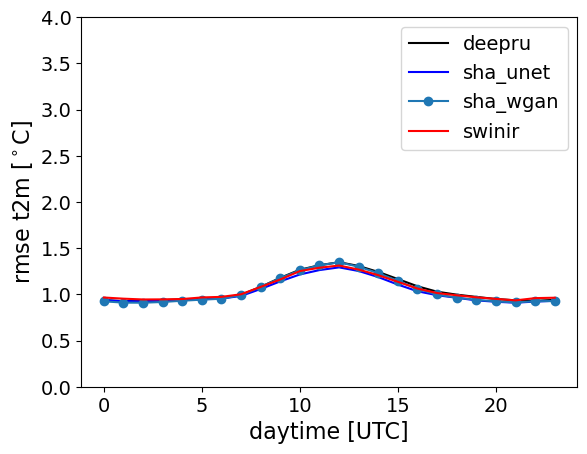

In [7]:
read_all_line_plots(config,uncertainty=False,metric_dict=metric_dict)

## **Box plot**
---
In the box plot all the competitive model are compared against a reference model

### **Config**

Define all the config parameters as before. You can use the same config variable as before in case analysis is done on the same parameters

In [2]:
#config parameters
config = {}
config['base_folder'] = "/p/scratch/deepacf/maelstrom/maelstrom_data/ap5/downscaling_benchmark_dataset/benchmark_t2m/results"
config['variable'] = "t2m"
config['models'] = ["deepru","sha_unet","sha_wgan","swinir"]
config['seasons'] = "year"   #["year","DJF","JJA","MAM","SON"]
config['metric'] = "grad_amplitude" #["bias","grad_amplitude","me_std","rmse"]                     
                                      

In [3]:
config = Config(**config)

## **Define parmaeters of the boxplot**

parameter of boxplot plotting routine

- config : Define an instance of **Config** <br />
- ref_model : reference or the baseline model to which the competitive models are compared to (reference model should be one of the models defined under the parameter of models in an instance of **Config** 


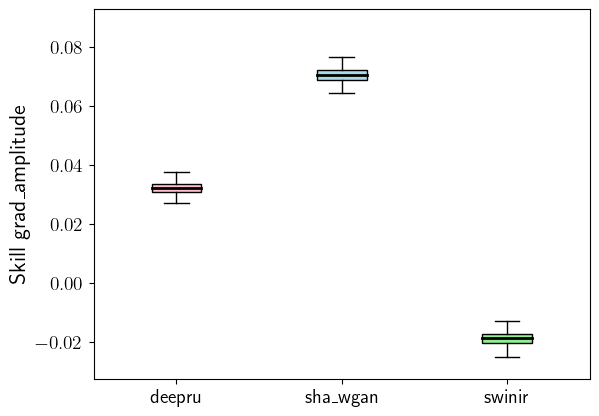

In [5]:
read_box_plot(config,ref_model="sha_unet")

# **Model Comparison**
---
Compare the differences between the forecast data and reference simulated data. Comparison is done for each competitive model

### **Config**

Define all the config parameters as before. You can use the same config variable as before in case analysis is done on the same parameters

In [2]:
config = {}
config['base_folder'] = "/p/scratch/deepacf/maelstrom/maelstrom_data/ap5/downscaling_benchmark_dataset/benchmark_t2m/results"
config['variable'] = "t2m"
config['models'] = ["deepru","sha_unet","sha_wgan","swinir"]
config['seasons'] = "JJA"   #["year","DJF","JJA","MAM","SON"]
config['metric'] = "rmse" #["bias","grad_amplitude","me_std","rmse"]                     


In [3]:
config = Config(**config)

### **Specify datetime** 

Pass datetime paramter to the conifg. It is intended to compare the performance for this partcular date and time (hour) of the day. <br />
If nothing is mentioned it will consider seasons parameter from the **config**


In [4]:
config.datetime = {"month" : "Jul" , 
                   "date" : 31,
                   "hour" : 14}

## **Parmameters for model comparison plot**

Only pass the **config** as the parameter of the model comparison routine 

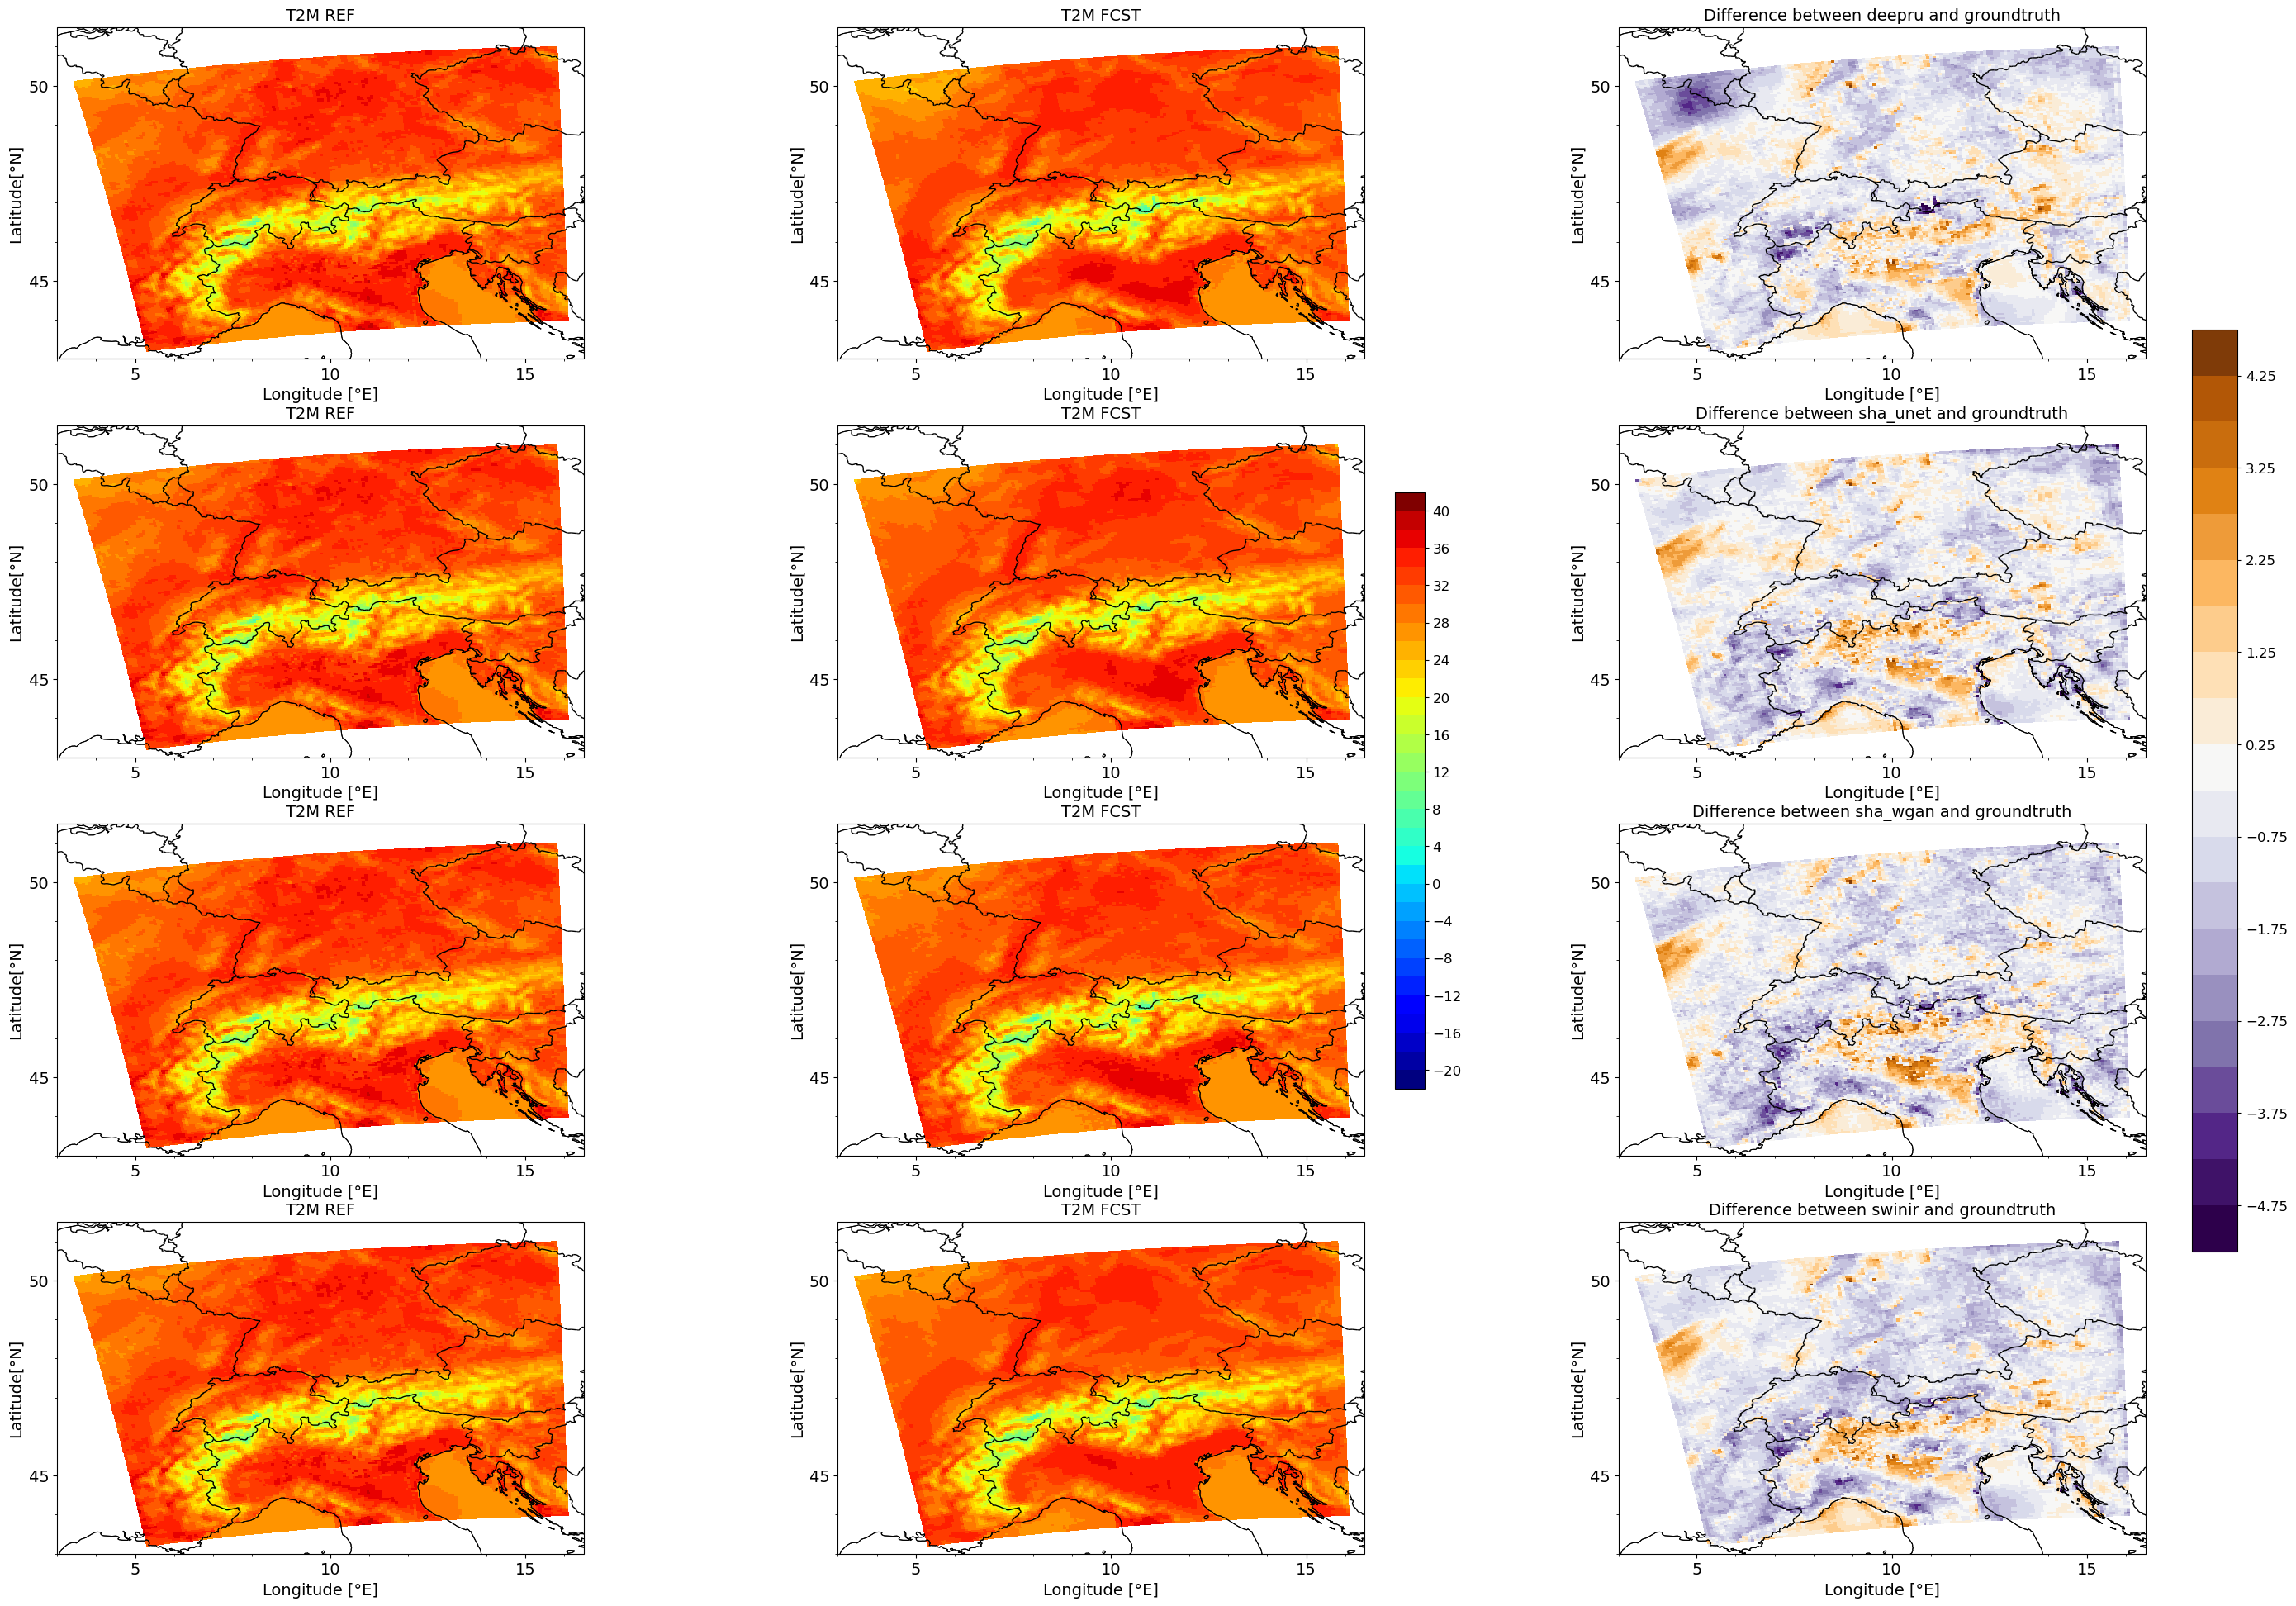

In [5]:
read_files_for_model_comparison(config)

## Energy Spectra